In [826]:
from pathlib import Path
import sys

from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    if "IPython.extensions.autoreload" not in ip.extension_manager.loaded:
        ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "lif_utils.py").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import lif_utils as lu
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

In [827]:
SHAPE_TEMPLATES = lu.make_toy_2d_shape_templates()
SHAPE_NAME = "seven"
SHAPE = SHAPE_TEMPLATES[SHAPE_NAME]

CANVAS_HEIGHT = 32
CANVAS_WIDTH = 64
INTENSITY = 1.0

MOTION_SPEED = 6
MOTION_START_TOP = 12
MOTION_START_LEFT = 12
MOTION_CONDITIONS = lu.make_default_2d_motion_conditions(
    canvas_height=CANVAS_HEIGHT,
    canvas_width=CANVAS_WIDTH,
    shape=SHAPE,
    speed=MOTION_SPEED,
    start_top=MOTION_START_TOP,
    start_left=MOTION_START_LEFT,
)
VELOCITIES = {
    name: (params["velocity_y"], params["velocity_x"])
    for name, params in MOTION_CONDITIONS.items()
}
VELOCITY_NAME = "right_fast"
VELOCITY_Y, VELOCITY_X = VELOCITIES[VELOCITY_NAME]

PREVIEW_TOP = 12
PREVIEW_LEFT = 12
STEPS = 6
SWEEP_STEPS = 5
T_PLOT = 4
OFFSETS = list(range(-24, 25))

BLUR_KERNEL_LENGTH = 9
BLUR_SIGMA_ALONG = 1.3
BLUR_SIGMA_ACROSS = 0.1
BLUR_GAIN = 1.2

LIF_BETA = 0.9
LIF_THRESHOLD = 0.75
BUFFER_SIZE = 4

COMMON_RUN_KWARGS = {
    "canvas_height": CANVAS_HEIGHT,
    "canvas_width": CANVAS_WIDTH,
    "intensity": INTENSITY,
    "blur_kernel_length": BLUR_KERNEL_LENGTH,
    "blur_sigma_along": BLUR_SIGMA_ALONG,
    "blur_sigma_across": BLUR_SIGMA_ACROSS,
    "blur_gain": BLUR_GAIN,
    "lif_beta": LIF_BETA,
    "lif_threshold": LIF_THRESHOLD,
    "buffer_size": BUFFER_SIZE,
    "offsets": OFFSETS,
}


### Preview selected shape

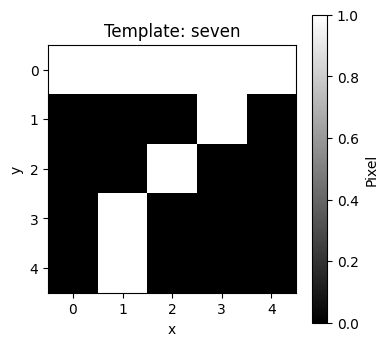

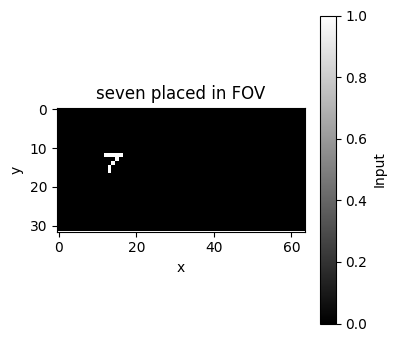

In [828]:
lu.plot_image(
    SHAPE,
    title=f"Template: {SHAPE_NAME}",
    colorbar_label="Pixel",
    vmin=0,
    vmax=1,
)

canvas = lu.place_shape_on_canvas(
    SHAPE,
    canvas_height=CANVAS_HEIGHT,
    canvas_width=CANVAS_WIDTH,
    top=PREVIEW_TOP,
    left=PREVIEW_LEFT,
    intensity=INTENSITY,
)

lu.plot_image(
    canvas,
    title=f"{SHAPE_NAME} placed in FOV",
    colorbar_label="Input",
    vmin=0,
    vmax=INTENSITY,
)


### Selected motion condition

In [829]:
selected_motion = MOTION_CONDITIONS[VELOCITY_NAME]

current_result = lu.run_motion_condition(
    condition_name=VELOCITY_NAME,
    velocity_y=selected_motion["velocity_y"],
    velocity_x=selected_motion["velocity_x"],
    start_top=selected_motion["start_top"],
    start_left=selected_motion["start_left"],
    shape=SHAPE,
    shape_name=SHAPE_NAME,
    steps=STEPS,
    t_plot=T_PLOT,
    **COMMON_RUN_KWARGS,
)

frames = current_result["frames"]
origins = current_result["origins"]
input_current = current_result["input_current"]
spk_rec_2d = current_result["spikes"]
mem_rec_2d = current_result["membrane"]
mem_buffered = current_result["naive_buffer"]
mem_motion_compensated = current_result["motion_comp_buffer"]

origins


[(12, 0), (12, 6), (12, 12), (12, 18), (12, 24), (12, 30)]

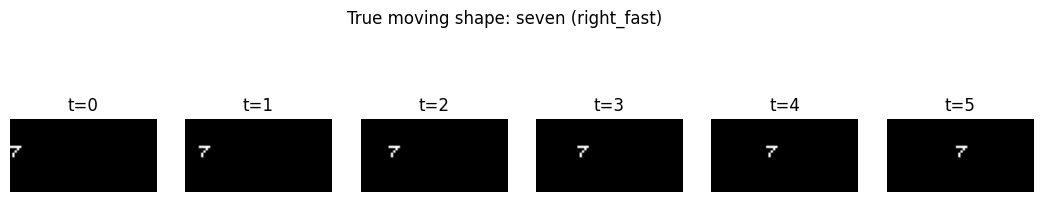

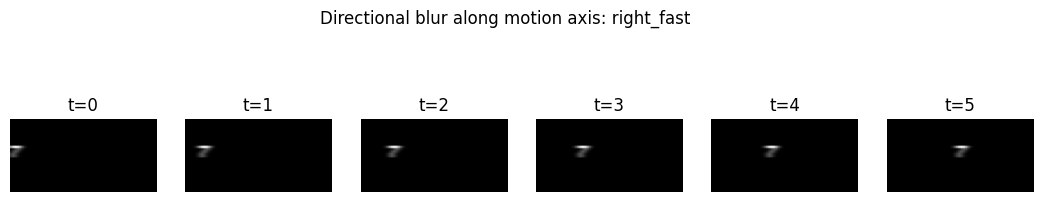

In [830]:
lu.plot_frame_sequence(
    frames,
    title=f"True moving shape: {SHAPE_NAME} ({VELOCITY_NAME})",
    vmin=0,
    vmax=INTENSITY,
)

lu.plot_frame_sequence(
    input_current,
    title=f"Directional blur along motion axis: {VELOCITY_NAME}",
    vmin=0,
    vmax=input_current.max().item(),
)


### LIF response

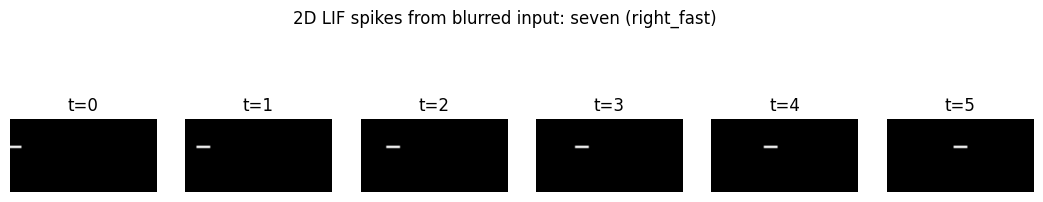

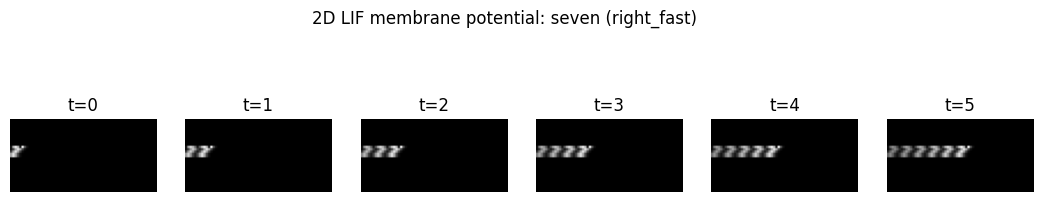

In [831]:
lu.plot_frame_sequence(
    spk_rec_2d,
    title=f"2D LIF spikes from blurred input: {SHAPE_NAME} ({VELOCITY_NAME})",
    vmin=0,
    vmax=1,
)

lu.plot_frame_sequence(
    mem_rec_2d,
    title=f"2D LIF membrane potential: {SHAPE_NAME} ({VELOCITY_NAME})",
    vmin=0,
    vmax=mem_rec_2d.max().item(),
)


The horizontal part of the seven creates spikes during horizontal motion. The rest of the shape mostly lives in the membrane as subthreshold evidence.

### Temporal buffers

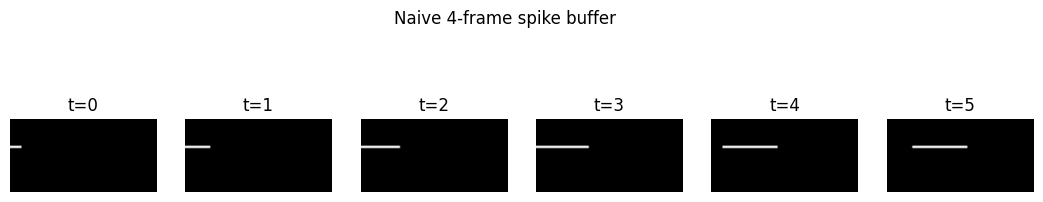

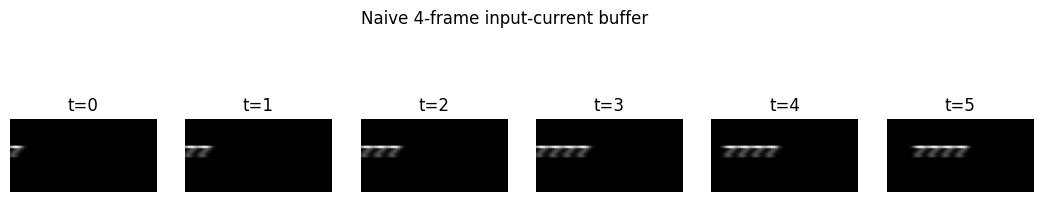

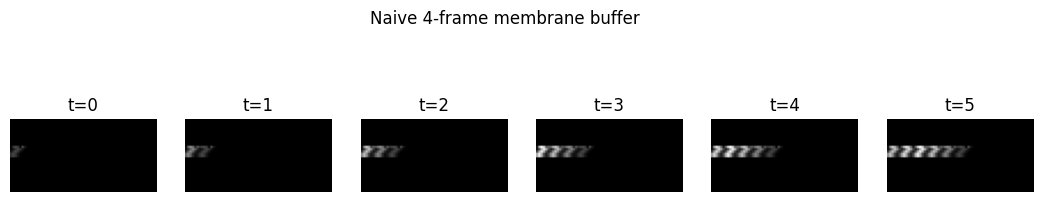

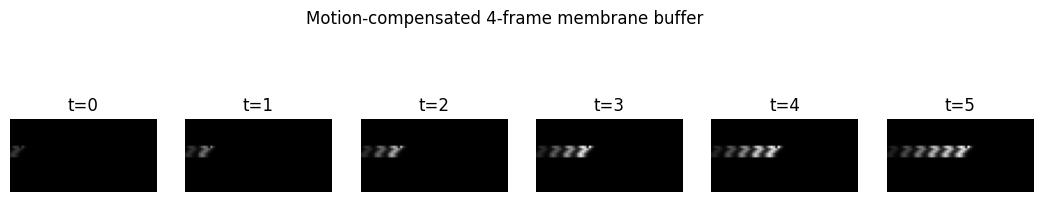

In [832]:
spike_buffered = lu.apply_2d_frame_buffer(
    spk_rec_2d,
    buffer_size=BUFFER_SIZE,
)
input_buffered = lu.apply_2d_frame_buffer(
    input_current,
    buffer_size=BUFFER_SIZE,
)

lu.plot_frame_sequence(
    spike_buffered,
    title=f"Naive {BUFFER_SIZE}-frame spike buffer",
    vmin=0,
    vmax=max(spike_buffered.max().item(), 1),
)

lu.plot_frame_sequence(
    input_buffered,
    title=f"Naive {BUFFER_SIZE}-frame input-current buffer",
    vmin=0,
    vmax=input_buffered.max().item(),
)

lu.plot_frame_sequence(
    mem_buffered,
    title=f"Naive {BUFFER_SIZE}-frame membrane buffer",
    vmin=0,
    vmax=mem_buffered.max().item(),
)

lu.plot_frame_sequence(
    mem_motion_compensated,
    title=f"Motion-compensated {BUFFER_SIZE}-frame membrane buffer",
    vmin=0,
    vmax=mem_motion_compensated.max().item(),
)


### Template localization

condition: right_fast
axis: x
velocity: (0, 6)

Spike summary:
{'total_spikes': 35, 'spikes_per_time': [5, 6, 6, 6, 6, 6], 'max_spikes_in_frame': 6}

Naive:
{'best_offset': -18, 'best_score': 0.43855054108250213, 'score_at_zero': 0.1291795675646083, 'max_off_target': 0.43855054108250213, 'dominance': 0.2945602673300631}

Motion-compensated:
{'best_offset': 0, 'best_score': 0.48545390345692474, 'score_at_zero': 0.48545390345692474, 'max_off_target': 0.4632772671922806, 'dominance': 1.047869013561483}


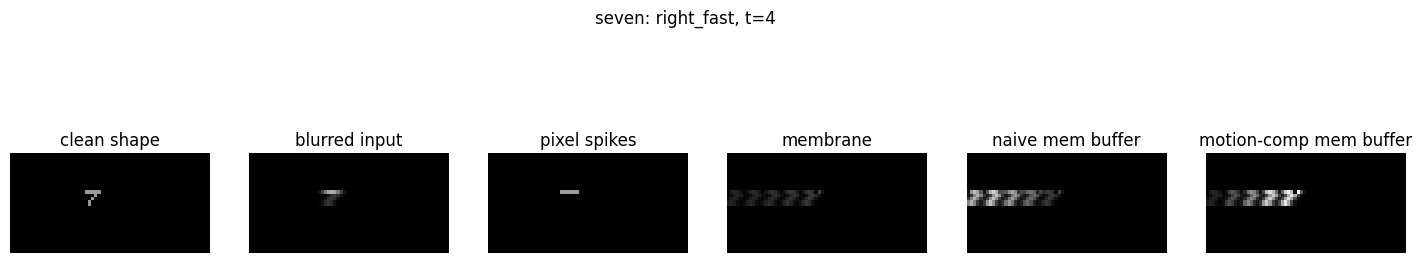

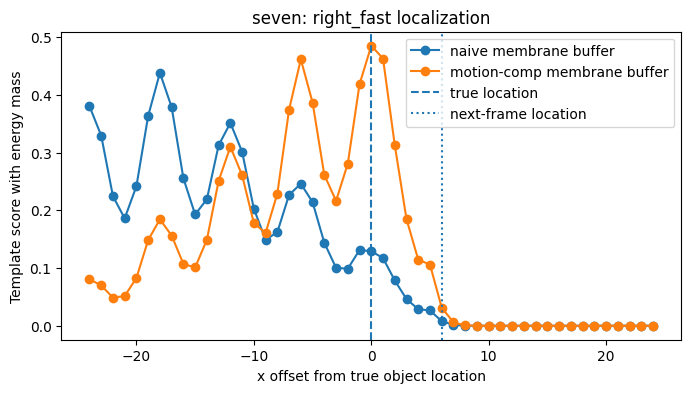

In [833]:
lu.print_motion_result_summary(current_result)

lu.plot_motion_condition_panel(
    current_result,
    t_plot=T_PLOT,
    title=f"{SHAPE_NAME}: {VELOCITY_NAME}, t={T_PLOT}",
)

lu.plot_localization_curve(
    current_result,
    title=f"{SHAPE_NAME}: {VELOCITY_NAME} localization",
)


### Sweep all motion directions

In [834]:
all_motion_results = lu.run_motion_conditions(
    motion_conditions=MOTION_CONDITIONS,
    shape=SHAPE,
    shape_name=SHAPE_NAME,
    steps=SWEEP_STEPS,
    t_plot=T_PLOT,
    verbose=False,
    **COMMON_RUN_KWARGS,
)

for result in all_motion_results.values():
    lu.print_motion_result_summary(result)

motion_summary_df = lu.motion_results_summary(all_motion_results)
motion_summary_df


condition: right_fast
axis: x
velocity: (0, 6)

Spike summary:
{'total_spikes': 29, 'spikes_per_time': [5, 6, 6, 6, 6], 'max_spikes_in_frame': 6}

Naive:
{'best_offset': -18, 'best_score': 0.43855054108250213, 'score_at_zero': 0.1291795675646083, 'max_off_target': 0.43855054108250213, 'dominance': 0.2945602673300631}

Motion-compensated:
{'best_offset': 0, 'best_score': 0.48545390345692474, 'score_at_zero': 0.48545390345692474, 'max_off_target': 0.4632772671922806, 'dominance': 1.047869013561483}
condition: left_fast
axis: x
velocity: (0, -6)

Spike summary:
{'total_spikes': 29, 'spikes_per_time': [5, 6, 6, 6, 6], 'max_spikes_in_frame': 6}

Naive:
{'best_offset': 18, 'best_score': 0.43650704788480443, 'score_at_zero': 0.12857763665625574, 'max_off_target': 0.43650704788480443, 'dominance': 0.2945602696078004}

Motion-compensated:
{'best_offset': 0, 'best_score': 0.4831918773874046, 'score_at_zero': 0.4831918773874046, 'max_off_target': 0.4596897773213078, 'dominance': 1.051125978245128

,condition,axis,velocity_y,velocity_x,naive_best_offset,naive_score_at_zero,naive_dominance,motion_best_offset,motion_score_at_zero,motion_dominance
0,right_fast,x,0,6,-18,0.129180,0.294560,0,0.485454,1.047869
1,left_fast,x,0,-6,18,0.128578,0.294560,0,0.483192,1.051126
2,down_fast,y,6,0,-18,0.152967,0.292553,0,0.594397,1.082908
3,up_fast,y,-6,0,18,0.143916,0.292553,0,0.559226,1.082908


### Result: motion-compensated membrane integration localizes latent shape evidence

In this toy 2D setting, the moving shape produces incomplete pixel-level spikes: only the strongest parts of the object cross threshold. However, the LIF membrane contains subthreshold evidence for the rest of the shape.

A naive temporal membrane buffer accumulates this evidence, but because the object is moving, the strongest template-like evidence remains at previous object locations. A motion-compensated membrane buffer shifts previous membrane states forward according to the known velocity before summing. Across rightward, leftward, downward, and upward motion, this moves the best template match to offset 0, the true current object location.

### Inspect one shape/motion pair

condition: right_faster
axis: x
velocity: (0, 10)

Spike summary:
{'total_spikes': 29, 'spikes_per_time': [5, 5, 5, 5, 5, 4], 'max_spikes_in_frame': 5}

Naive:
{'best_offset': -19, 'best_score': 0.550208096897984, 'score_at_zero': 0.1692431865132068, 'max_off_target': 0.550208096897984, 'dominance': 0.30759849662590805}

Motion-compensated:
{'best_offset': -1, 'best_score': 0.771881639957428, 'score_at_zero': 0.6769727460528272, 'max_off_target': 0.771881639957428, 'dominance': 0.8770421554783232}


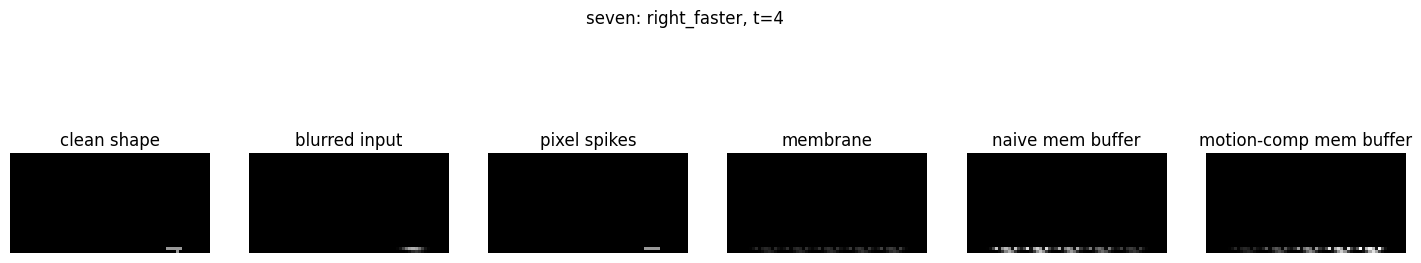

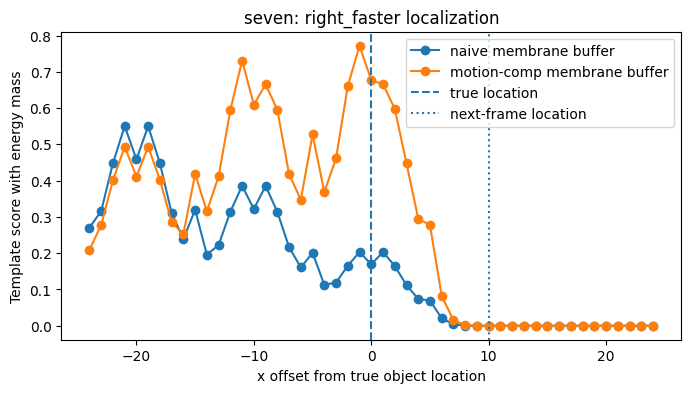

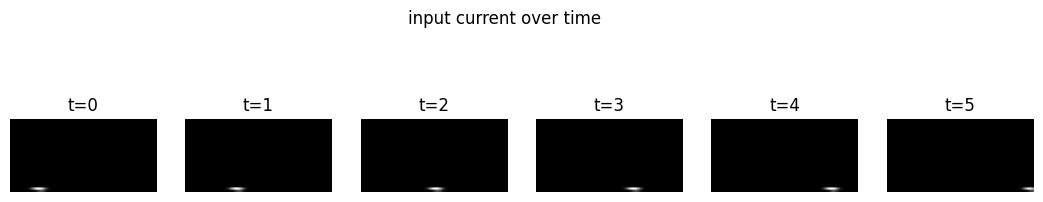

In [943]:
box_result = lu.inspect_motion_condition(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=MOTION_CONDITIONS,
    shape_name="seven",
    condition_name="right_faster",
    steps=STEPS,
    t_plot=T_PLOT,
    **COMMON_RUN_KWARGS,
)

lu.plot_input_current_over_time(
    box_result,
    title="input current over time",
)


### Spike visibility across shapes

In [836]:
spike_summary_df = lu.spike_summary_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=MOTION_CONDITIONS,
    steps=SWEEP_STEPS,
    t_plot=T_PLOT,
    **COMMON_RUN_KWARGS,
)

spike_summary_df


,shape,condition,velocity_y,velocity_x,total_spikes,max_spikes_in_frame,spikes_per_time
0,seven,right_fast,0,6,29,6,"[5, 6, 6, 6, 6]"
1,seven,left_fast,0,-6,29,6,"[5, 6, 6, 6, 6]"
2,seven,down_fast,6,0,0,0,"[0, 0, 0, 0, 0]"
3,seven,up_fast,-6,0,0,0,"[0, 0, 0, 0, 0]"
4,ell,right_fast,0,6,29,6,"[5, 6, 6, 6, 6]"
5,ell,left_fast,0,-6,29,6,"[5, 6, 6, 6, 6]"
6,ell,down_fast,6,0,29,6,"[5, 6, 6, 6, 6]"
7,ell,up_fast,-6,0,29,6,"[5, 6, 6, 6, 6]"
8,tee,right_fast,0,6,29,6,"[5, 6, 6, 6, 6]"
9,tee,left_fast,0,-6,29,6,"[5, 6, 6, 6, 6]"


In [837]:
spike_pivot = spike_summary_df.pivot(
    index="shape",
    columns="condition",
    values="total_spikes",
)

spike_pivot


condition,down_fast,left_fast,right_fast,up_fast
shape,,,,
box,58,58,58,58
ell,29,29,29,29
seven,0,29,29,0
tee,29,29,29,29


### Observation: spike visibility depends on alignment between shape structure and motion

Pixel-level spikes are not a complete representation of the object. Spikes appear mainly when part of the shape is aligned with the motion direction, because directional blur reinforces those pixels enough to cross threshold. The membrane can still contain structured subthreshold evidence even when the emitted spike stream contains few or no object spikes.

### Combined spike and localization summary

In [838]:
combined_summary_df = lu.combined_motion_summary_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=MOTION_CONDITIONS,
    steps=SWEEP_STEPS,
    t_plot=T_PLOT,
    **COMMON_RUN_KWARGS,
)

combined_summary_df


,shape,condition,velocity_y,velocity_x,total_spikes,naive_best_offset,naive_score_at_zero,naive_dominance,motion_best_offset,motion_score_at_zero,motion_dominance
0,seven,right_fast,0,6,29,-18,0.129180,0.294560,0,0.485454,1.047869
1,seven,left_fast,0,-6,29,18,0.128578,0.294560,0,0.483192,1.051126
2,seven,down_fast,6,0,0,-18,0.152967,0.292553,0,0.594397,1.082908
3,seven,up_fast,-6,0,0,18,0.143916,0.292553,0,0.559226,1.082908
4,ell,right_fast,0,6,29,-18,0.164682,0.294560,0,0.618870,1.047869
5,ell,left_fast,0,-6,29,18,0.147440,0.294560,0,0.554077,1.051126
6,ell,down_fast,6,0,29,-18,0.147440,0.294560,0,0.554077,1.051126
7,ell,up_fast,-6,0,29,18,0.164682,0.294560,0,0.618870,1.047869
8,tee,right_fast,0,6,29,-18,0.123751,0.294560,0,0.465053,1.047869
9,tee,left_fast,0,-6,29,18,0.123751,0.294560,0,0.465053,1.047869


In [839]:
combined_summary_df[
    combined_summary_df["shape"] == "seven"
]


,shape,condition,velocity_y,velocity_x,total_spikes,naive_best_offset,naive_score_at_zero,naive_dominance,motion_best_offset,motion_score_at_zero,motion_dominance
0,seven,right_fast,0,6,29,-18,0.129180,0.294560,0,0.485454,1.047869
1,seven,left_fast,0,-6,29,18,0.128578,0.294560,0,0.483192,1.051126
2,seven,down_fast,6,0,0,-18,0.152967,0.292553,0,0.594397,1.082908
3,seven,up_fast,-6,0,0,18,0.143916,0.292553,0,0.559226,1.082908


### Experiment: velocity-estimation sensitivity

The true object velocity is fixed, but the compensation velocity may be wrong.

In [840]:
FASTER_CANVAS_HEIGHT = 64
FASTER_CANVAS_WIDTH = 64
FASTER_STEPS = 5
FASTER_T_PLOT = 4
FASTER_MOTION_SPEED = 10

FASTER_MOTION_CONDITIONS = {
    "right_faster": {
        "velocity_y": 0,
        "velocity_x": FASTER_MOTION_SPEED,
        "start_top": 30,
        "start_left": 10,
    },
    "left_faster": {
        "velocity_y": 0,
        "velocity_x": -FASTER_MOTION_SPEED,
        "start_top": 30,
        "start_left": 42,
    },
    "down_faster": {
        "velocity_y": FASTER_MOTION_SPEED,
        "velocity_x": 0,
        "start_top": 10,
        "start_left": 30,
    },
    "up_faster": {
        "velocity_y": -FASTER_MOTION_SPEED,
        "velocity_x": 0,
        "start_top": 42,
        "start_left": 30,
    },
}

VELOCITY_SENSITIVITY_KWARGS = {
    "canvas_height": FASTER_CANVAS_HEIGHT,
    "canvas_width": FASTER_CANVAS_WIDTH,
    "steps": FASTER_STEPS,
    "t_plot": FASTER_T_PLOT,
    "intensity": INTENSITY,
    "blur_kernel_length": BLUR_KERNEL_LENGTH,
    "blur_sigma_along": BLUR_SIGMA_ALONG,
    "blur_sigma_across": BLUR_SIGMA_ACROSS,
    "blur_gain": BLUR_GAIN,
    "lif_beta": LIF_BETA,
    "lif_threshold": LIF_THRESHOLD,
    "buffer_size": BUFFER_SIZE,
}


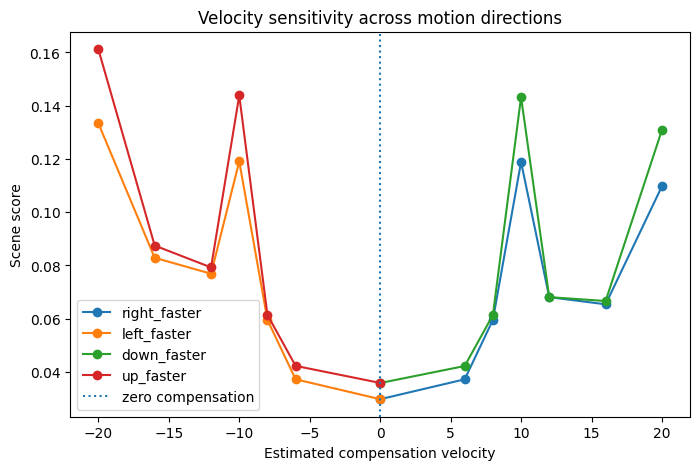

In [841]:
velocity_sensitivity_faster = lu.run_velocity_sensitivity_by_condition(
    shape_name=SHAPE_NAME,
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=FASTER_MOTION_CONDITIONS,
    **VELOCITY_SENSITIVITY_KWARGS,
)

lu.plot_velocity_scene_score_by_condition(
    velocity_sensitivity_faster,
)


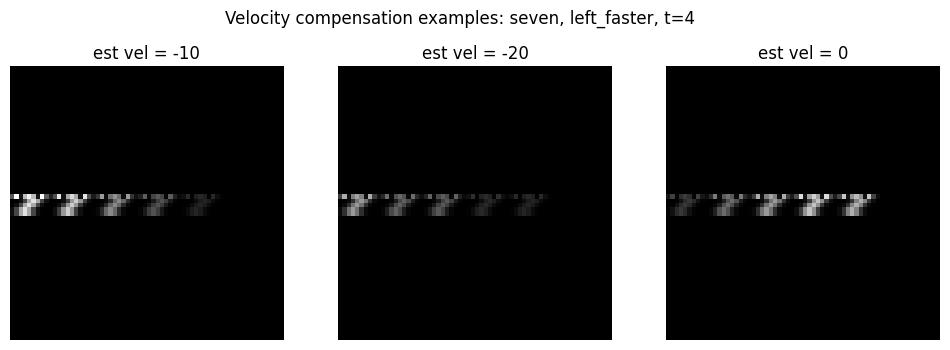

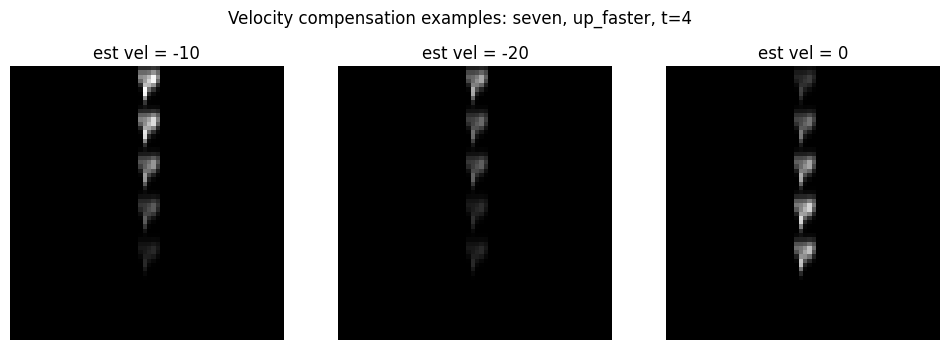

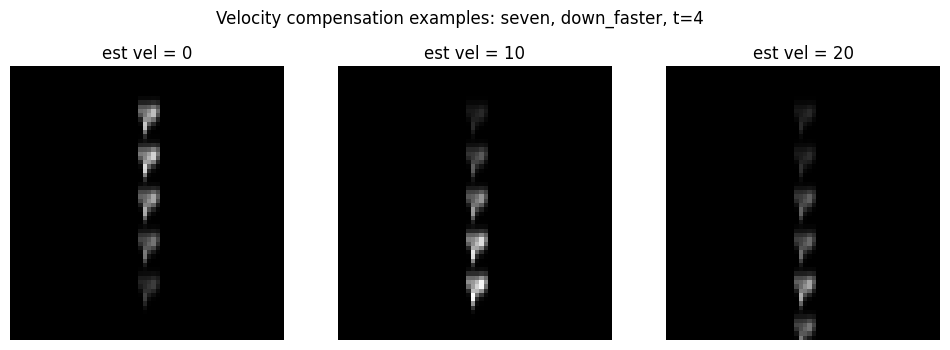

In [842]:
lu.plot_compensated_velocity_examples(
    velocity_sensitivity_faster["left_faster"],
    velocities_to_show=[-10, -20, 0],
    t_plot=FASTER_T_PLOT,
)

lu.plot_compensated_velocity_examples(
    velocity_sensitivity_faster["up_faster"],
    velocities_to_show=[-10, -20, 0],
    t_plot=FASTER_T_PLOT,
)

lu.plot_compensated_velocity_examples(
    velocity_sensitivity_faster["down_faster"],
    velocities_to_show=[0, 10, 20],
    t_plot=FASTER_T_PLOT,
)


### Diagnosis

A normalized scene score can favor overcompensated, thinner reconstructions because it rewards concentration while ignoring lost or residual membrane energy.

### Target-mask diagnostics

In [843]:
target_mask_scores_left = lu.compare_target_mask_scores(
    velocity_sensitivity_faster["left_faster"],
    t_plot=FASTER_T_PLOT,
    threshold_fraction=0.25,
    buffer_size=BUFFER_SIZE,
)

target_mask_scores_left


,estimated_velocity,hard_target_mask_score,soft_target_mask_score
0,-20,0.177026,0.187547
1,-16,0.114749,0.124234
2,-12,0.110662,0.119013
3,-10,0.158001,0.167383
4,-8,0.081581,0.086409
5,-6,0.050829,0.054249
6,0,0.039447,0.041800


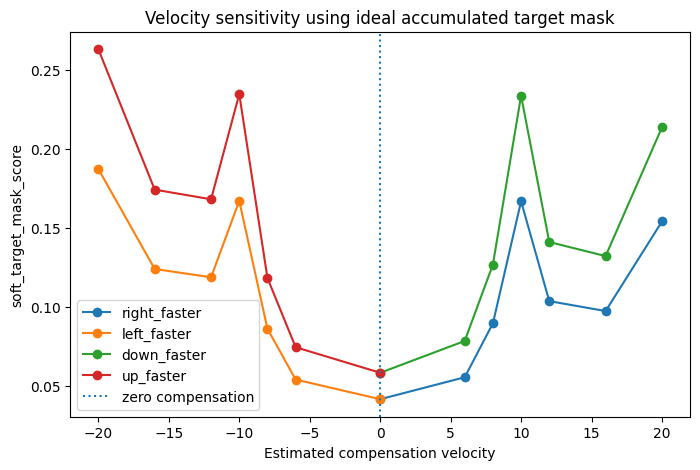

In [844]:
lu.plot_target_mask_score_by_condition(
    velocity_sensitivity_faster,
    score_column="soft_target_mask_score",
    t_plot=FASTER_T_PLOT,
    threshold_fraction=0.25,
    buffer_size=BUFFER_SIZE,
)


## Successful metric

The weighted target-residual score rewards energy on the ideal target mask and subtracts a small penalty for residual energy elsewhere.

In [845]:
lu.weighted_target_residual_score(
    velocity_sensitivity_faster["left_faster"],
    t_plot=FASTER_T_PLOT,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)


,estimated_velocity,target_energy,residual_energy,score
0,-20,9.148245,42.529060,7.021792
1,-16,6.734874,51.957363,4.137006
2,-12,8.388872,67.417442,5.018000
3,-10,13.502945,71.958344,9.905028
4,-8,6.981447,78.595810,3.051657
5,-6,4.349811,81.227448,0.288438
6,0,3.375736,82.201523,-0.734340


In [846]:
velocity_sensitivity_all_shapes = lu.run_velocity_sensitivity_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=FASTER_MOTION_CONDITIONS,
    **VELOCITY_SENSITIVITY_KWARGS,
)

weighted_metric_summary = lu.summarize_weighted_metric_across_shapes(
    velocity_sensitivity_all_shapes,
    t_plot=FASTER_T_PLOT,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

weighted_metric_summary


,shape,condition,true_velocity,best_estimated_velocity,velocity_error,best_score,target_energy_at_best,residual_energy_at_best,correct_velocity_wins
0,seven,right_faster,10,10.0,0.0,9.897296,13.502945,72.112976,True
1,seven,left_faster,-10,-10.0,0.0,9.905028,13.502945,71.958344,True
2,seven,down_faster,10,10.0,0.0,32.456789,37.156765,93.999519,True
3,seven,up_faster,-10,-10.0,0.0,32.486375,37.156765,93.407806,True
4,ell,right_faster,10,10.0,0.0,9.897295,13.502944,72.112976,True
5,ell,left_faster,-10,-10.0,0.0,9.926881,13.502944,71.521255,True
6,ell,down_faster,10,10.0,0.0,9.897297,13.502945,72.112968,True
7,ell,up_faster,-10,-10.0,0.0,9.903732,13.502945,71.984268,True
8,tee,right_faster,10,10.0,0.0,9.897296,13.502945,72.112976,True
9,tee,left_faster,-10,-10.0,0.0,9.903732,13.502945,71.984253,True


In [847]:
weighted_metric_summary[
    weighted_metric_summary["shape"] == "seven"
][[
    "condition",
    "true_velocity",
    "best_estimated_velocity",
    "best_score",
    "target_energy_at_best",
    "residual_energy_at_best",
]]


,condition,true_velocity,best_estimated_velocity,best_score,target_energy_at_best,residual_energy_at_best
0,right_faster,10,10.0,9.897296,13.502945,72.112976
1,left_faster,-10,-10.0,9.905028,13.502945,71.958344
2,down_faster,10,10.0,32.456789,37.156765,93.999519
3,up_faster,-10,-10.0,32.486375,37.156765,93.407806


## Moving on to velocity estimation

In [857]:
CANVAS_HEIGHT = 64
CANVAS_WIDTH = 64

MOTION_CONDITIONS = {
    "right_faster": {
        "velocity_y": 0,
        "velocity_x": 10,
        "start_top": 30,
        "start_left": 10,
    },
    "left_faster": {
        "velocity_y": 0,
        "velocity_x": -10,
        "start_top": 30,
        "start_left": 42,
    },
    "down_faster": {
        "velocity_y": 10,
        "velocity_x": 0,
        "start_top": 10,
        "start_left": 30,
    },
    "up_faster": {
        "velocity_y": -10,
        "velocity_x": 0,
        "start_top": 42,
        "start_left": 30,
    },
}

In [858]:
velocity_sensitivity_all_shapes = lu.run_velocity_sensitivity_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=MOTION_CONDITIONS,
    canvas_height=CANVAS_HEIGHT,
    canvas_width=CANVAS_WIDTH,
    steps=5,
    t_plot=4,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=BUFFER_SIZE,
)

In [859]:
def estimate_velocity_from_reconstruction(
    sensitivity_result,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    """
    Estimate velocity by choosing the candidate velocity with the best
    weighted target-residual reconstruction score.
    """
    scores = lu.weighted_target_residual_score(
        sensitivity_result,
        t_plot=t_plot,
        threshold_fraction=threshold_fraction,
        residual_penalty=residual_penalty,
        buffer_size=buffer_size,
    )

    best_row = scores.loc[scores["score"].idxmax()]
    true_velocity = sensitivity_result["sensitivity_df"]["true_velocity"].iloc[0]

    return {
        "true_velocity": true_velocity,
        "estimated_velocity": best_row["estimated_velocity"],
        "velocity_error": best_row["estimated_velocity"] - true_velocity,
        "score": best_row["score"],
        "target_energy": best_row["target_energy"],
        "residual_energy": best_row["residual_energy"],
        "scores": scores,
    }

In [860]:
velocity_estimate = estimate_velocity_from_reconstruction(
    velocity_sensitivity_all_shapes["seven"]["left_faster"],
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

velocity_estimate

{'true_velocity': np.int64(-10),
 'estimated_velocity': np.float64(-10.0),
 'velocity_error': np.float64(0.0),
 'score': np.float64(9.905027770996094),
 'target_energy': np.float64(13.502944946289062),
 'residual_energy': np.float64(71.95834350585938),
 'scores':    estimated_velocity  target_energy  residual_energy     score
 0                 -20       9.148245        42.529060  7.021792
 1                 -16       6.734874        51.957363  4.137006
 2                 -12       8.388872        67.417442  5.018000
 3                 -10      13.502945        71.958344  9.905028
 4                  -8       6.981447        78.595810  3.051657
 5                  -6       4.349811        81.227448  0.288438
 6                   0       3.375736        82.201523 -0.734340}

In [861]:
def estimate_velocity_across_shapes(
    velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    rows = []

    for shape_name, condition_results in velocity_sensitivity_all_shapes.items():
        for condition_name, sensitivity_result in condition_results.items():
            estimate = estimate_velocity_from_reconstruction(
                sensitivity_result,
                t_plot=t_plot,
                threshold_fraction=threshold_fraction,
                residual_penalty=residual_penalty,
                buffer_size=buffer_size,
            )

            rows.append({
                "shape": shape_name,
                "condition": condition_name,
                "true_velocity": estimate["true_velocity"],
                "estimated_velocity": estimate["estimated_velocity"],
                "velocity_error": estimate["velocity_error"],
                "score": estimate["score"],
                "target_energy": estimate["target_energy"],
                "residual_energy": estimate["residual_energy"],
                "correct": estimate["estimated_velocity"] == estimate["true_velocity"],
            })

    return pd.DataFrame(rows)


velocity_estimation_summary = estimate_velocity_across_shapes(
    velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

velocity_estimation_summary

,shape,condition,true_velocity,estimated_velocity,velocity_error,score,target_energy,residual_energy,correct
0,seven,right_faster,10,10.0,0.0,9.897296,13.502945,72.112976,True
1,seven,left_faster,-10,-10.0,0.0,9.905028,13.502945,71.958344,True
2,seven,down_faster,10,10.0,0.0,32.456789,37.156765,93.999519,True
3,seven,up_faster,-10,-10.0,0.0,32.486375,37.156765,93.407806,True
4,ell,right_faster,10,10.0,0.0,9.897295,13.502944,72.112976,True
5,ell,left_faster,-10,-10.0,0.0,9.926881,13.502944,71.521255,True
6,ell,down_faster,10,10.0,0.0,9.897297,13.502945,72.112968,True
7,ell,up_faster,-10,-10.0,0.0,9.903732,13.502945,71.984268,True
8,tee,right_faster,10,10.0,0.0,9.897296,13.502945,72.112976,True
9,tee,left_faster,-10,-10.0,0.0,9.903732,13.502945,71.984253,True


Successful speed detectio giving that we know direction 

In [862]:
def make_axis_aligned_velocity_candidates(speeds=None):
    """
    Candidate 2D velocities for unknown direction.

    We test horizontal and vertical motion hypotheses:
    left/right: (0, vx)
    up/down:    (vy, 0)
    """
    if speeds is None:
        speeds = [-20, -16, -12, -10, -8, -6, 0, 6, 8, 10, 12, 16, 20]

    candidates = []

    for speed in speeds:
        candidates.append((0, speed))   # horizontal hypothesis
        candidates.append((speed, 0))   # vertical hypothesis

    # remove duplicate (0, 0)
    candidates = list(dict.fromkeys(candidates))

    return candidates

In [863]:
def score_candidate_velocity_pair(
    sensitivity_result,
    estimated_velocity_y,
    estimated_velocity_x,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    base = sensitivity_result["base_result"]

    target = lu.make_ideal_compensated_target(
        sensitivity_result,
        t_plot=t_plot,
        buffer_size=buffer_size,
    )

    target_mask = lu.make_binary_target_mask(
        target,
        threshold_fraction=threshold_fraction,
    )

    mem_compensated = lu.apply_motion_compensated_2d_buffer_with_estimated_velocity(
        base["membrane"],
        buffer_size=buffer_size,
        estimated_velocity_y=estimated_velocity_y,
        estimated_velocity_x=estimated_velocity_x,
    )

    frame = torch.clamp(mem_compensated[t_plot], min=0)

    target_energy = (frame * target_mask).sum().item()
    residual_energy = (frame * (1.0 - target_mask)).sum().item()
    score = target_energy - residual_penalty * residual_energy

    return {
        "estimated_velocity_y": estimated_velocity_y,
        "estimated_velocity_x": estimated_velocity_x,
        "target_energy": target_energy,
        "residual_energy": residual_energy,
        "score": score,
    }

In [864]:
def estimate_unknown_axis_velocity(
    sensitivity_result,
    candidate_velocity_pairs=None,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    if candidate_velocity_pairs is None:
        candidate_velocity_pairs = make_axis_aligned_velocity_candidates()

    rows = []

    for estimated_velocity_y, estimated_velocity_x in candidate_velocity_pairs:
        row = score_candidate_velocity_pair(
            sensitivity_result,
            estimated_velocity_y=estimated_velocity_y,
            estimated_velocity_x=estimated_velocity_x,
            t_plot=t_plot,
            threshold_fraction=threshold_fraction,
            residual_penalty=residual_penalty,
            buffer_size=buffer_size,
        )
        rows.append(row)

    scores = pd.DataFrame(rows).sort_values("score", ascending=False)

    base = sensitivity_result["base_result"]
    true_axis = base["axis"]
    true_velocity = sensitivity_result["sensitivity_df"]["true_velocity"].iloc[0]

    if true_axis == "x":
        true_velocity_y = 0
        true_velocity_x = true_velocity
    else:
        true_velocity_y = true_velocity
        true_velocity_x = 0

    best = scores.iloc[0]

    return {
        "true_velocity_y": true_velocity_y,
        "true_velocity_x": true_velocity_x,
        "estimated_velocity_y": best["estimated_velocity_y"],
        "estimated_velocity_x": best["estimated_velocity_x"],
        "correct": (
            best["estimated_velocity_y"] == true_velocity_y
            and best["estimated_velocity_x"] == true_velocity_x
        ),
        "scores": scores,
    }

In [865]:
unknown_velocity_estimate = estimate_unknown_axis_velocity(
    velocity_sensitivity_all_shapes["seven"]["left_faster"],
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

unknown_velocity_estimate

{'true_velocity_y': 0,
 'true_velocity_x': np.int64(-10),
 'estimated_velocity_y': np.float64(0.0),
 'estimated_velocity_x': np.float64(-10.0),
 'correct': np.True_,
 'scores':     estimated_velocity_y  estimated_velocity_x  target_energy  \
 6                      0                   -10      13.502945   
 0                      0                   -20       9.148245   
 4                      0                   -12       8.388872   
 2                      0                   -16       6.734874   
 8                      0                    -8       6.981447   
 1                    -20                     0       3.375736   
 24                    20                     0       3.375736   
 23                     0                    20       3.375736   
 21                     0                    16       3.375736   
 22                    16                     0       3.375736   
 3                    -16                     0       3.375736   
 10                     0       

In [866]:
def estimate_unknown_axis_velocity_across_shapes(
    velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    rows = []

    for shape_name, condition_results in velocity_sensitivity_all_shapes.items():
        for condition_name, sensitivity_result in condition_results.items():
            estimate = estimate_unknown_axis_velocity(
                sensitivity_result,
                t_plot=t_plot,
                threshold_fraction=threshold_fraction,
                residual_penalty=residual_penalty,
                buffer_size=buffer_size,
            )

            rows.append({
                "shape": shape_name,
                "condition": condition_name,
                "true_velocity_y": estimate["true_velocity_y"],
                "true_velocity_x": estimate["true_velocity_x"],
                "estimated_velocity_y": estimate["estimated_velocity_y"],
                "estimated_velocity_x": estimate["estimated_velocity_x"],
                "correct": estimate["correct"],
            })

    return pd.DataFrame(rows)


unknown_axis_velocity_summary = estimate_unknown_axis_velocity_across_shapes(
    velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

unknown_axis_velocity_summary

,shape,condition,true_velocity_y,true_velocity_x,estimated_velocity_y,estimated_velocity_x,correct
0,seven,right_faster,0,10,0.0,10.0,True
1,seven,left_faster,0,-10,0.0,-10.0,True
2,seven,down_faster,10,0,10.0,0.0,True
3,seven,up_faster,-10,0,-10.0,0.0,True
4,ell,right_faster,0,10,0.0,10.0,True
5,ell,left_faster,0,-10,0.0,-10.0,True
6,ell,down_faster,10,0,10.0,0.0,True
7,ell,up_faster,-10,0,-10.0,0.0,True
8,tee,right_faster,0,10,0.0,10.0,True
9,tee,left_faster,0,-10,0.0,-10.0,True


Success wihtout knowing direction

## Moving to any direction velocities

First need to validate the velocity estimation metric

In [872]:
def run_2d_velocity_vector_sensitivity_experiment(
    shape_name,
    condition_name,
    shape_templates,
    motion_conditions,
    candidate_velocity_pairs,
    canvas_height=64,
    canvas_width=64,
    steps=5,
    t_plot=4,
    intensity=1.0,
    blur_kernel_length=9,
    blur_sigma_along=1.3,
    blur_sigma_across=0.1,
    blur_gain=1.2,
    lif_beta=0.9,
    lif_threshold=0.75,
    buffer_size=4,
):
    shape = shape_templates[shape_name]
    params = motion_conditions[condition_name]

    true_velocity_y = params["velocity_y"]
    true_velocity_x = params["velocity_x"]

    frames, origins = lu.make_moving_2d_shape(
        shape=shape,
        canvas_height=canvas_height,
        canvas_width=canvas_width,
        steps=steps,
        start_top=params["start_top"],
        start_left=params["start_left"],
        velocity_y=true_velocity_y,
        velocity_x=true_velocity_x,
        intensity=intensity,
    )

    input_current = lu.apply_directional_blur_to_frames(
        frames,
        velocity_y=true_velocity_y,
        velocity_x=true_velocity_x,
        kernel_length=blur_kernel_length,
        sigma_along=blur_sigma_along,
        sigma_across=blur_sigma_across,
        gain=blur_gain,
    )

    spikes, membrane = lu.run_lif_2d_layer(
        input_current,
        beta=lif_beta,
        threshold=lif_threshold,
    )

    base_result = {
        "shape_name": shape_name,
        "condition": condition_name,
        "frames": frames,
        "input_current": input_current,
        "spikes": spikes,
        "membrane": membrane,
        "origins": origins,
        "true_velocity_y": true_velocity_y,
        "true_velocity_x": true_velocity_x,
        "t_plot": t_plot,
    }

    rows = []
    compensated_frames_by_velocity = {}

    for estimated_velocity_y, estimated_velocity_x in candidate_velocity_pairs:
        mem_compensated = lu.apply_motion_compensated_2d_buffer_with_estimated_velocity(
            membrane,
            buffer_size=buffer_size,
            estimated_velocity_y=estimated_velocity_y,
            estimated_velocity_x=estimated_velocity_x,
        )

        velocity_key = (estimated_velocity_y, estimated_velocity_x)
        compensated_frames_by_velocity[velocity_key] = mem_compensated

        rows.append({
            "shape": shape_name,
            "condition": condition_name,
            "true_velocity_y": true_velocity_y,
            "true_velocity_x": true_velocity_x,
            "estimated_velocity_y": estimated_velocity_y,
            "estimated_velocity_x": estimated_velocity_x,
            "velocity_y_error": estimated_velocity_y - true_velocity_y,
            "velocity_x_error": estimated_velocity_x - true_velocity_x,
        })

    return {
        "base_result": base_result,
        "sensitivity_df": pd.DataFrame(rows),
        "compensated_frames_by_velocity": compensated_frames_by_velocity,
    }


def make_ideal_compensated_target_2d_vector(
    sensitivity_result,
    t_plot=4,
    buffer_size=4,
):
    base = sensitivity_result["base_result"]

    ideal_compensated_input = lu.apply_motion_compensated_2d_buffer_with_estimated_velocity(
        base["input_current"],
        buffer_size=buffer_size,
        estimated_velocity_y=base["true_velocity_y"],
        estimated_velocity_x=base["true_velocity_x"],
    )

    return ideal_compensated_input[t_plot]


def weighted_target_residual_score_2d_vectors(
    sensitivity_result,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    target = make_ideal_compensated_target_2d_vector(
        sensitivity_result,
        t_plot=t_plot,
        buffer_size=buffer_size,
    )

    target_mask = lu.make_binary_target_mask(
        target,
        threshold_fraction=threshold_fraction,
    )

    rows = []

    for velocity_key, mem_compensated in sensitivity_result["compensated_frames_by_velocity"].items():
        estimated_velocity_y, estimated_velocity_x = velocity_key

        frame = torch.clamp(mem_compensated[t_plot], min=0)

        target_energy = (frame * target_mask).sum().item()
        residual_energy = (frame * (1.0 - target_mask)).sum().item()
        score = target_energy - residual_penalty * residual_energy

        rows.append({
            "estimated_velocity_y": estimated_velocity_y,
            "estimated_velocity_x": estimated_velocity_x,
            "target_energy": target_energy,
            "residual_energy": residual_energy,
            "score": score,
        })

    return pd.DataFrame(rows).sort_values("score", ascending=False)

In [868]:
MIXED_2D_MOTION_CONDITIONS = {
    "down_right_10_12": {
        "velocity_y": 10,
        "velocity_x": 12,
        "start_top": 6,
        "start_left": 6,
    },
    "down_left_10_12": {
        "velocity_y": 10,
        "velocity_x": -12,
        "start_top": 6,
        "start_left": 54,
    },
    "up_right_10_12": {
        "velocity_y": -10,
        "velocity_x": 12,
        "start_top": 54,
        "start_left": 6,
    },
    "up_left_10_12": {
        "velocity_y": -10,
        "velocity_x": -12,
        "start_top": 54,
        "start_left": 54,
    },

    "down_right_12_10": {
        "velocity_y": 12,
        "velocity_x": 10,
        "start_top": 6,
        "start_left": 6,
    },
    "down_left_12_10": {
        "velocity_y": 12,
        "velocity_x": -10,
        "start_top": 6,
        "start_left": 54,
    },
    "up_right_12_10": {
        "velocity_y": -12,
        "velocity_x": 10,
        "start_top": 54,
        "start_left": 6,
    },
    "up_left_12_10": {
        "velocity_y": -12,
        "velocity_x": -10,
        "start_top": 54,
        "start_left": 54,
    },
}

In [869]:
def make_fast_mixed_2d_velocity_candidates():
    y_candidates = [-16, -14, -12, -10, -8, 0, 8, 10, 12, 14, 16]
    x_candidates = [-16, -14, -12, -10, -8, 0, 8, 10, 12, 14, 16]

    candidates = []

    for vy in y_candidates:
        for vx in x_candidates:
            candidates.append((vy, vx))

    return candidates


MIXED_2D_VELOCITY_CANDIDATES = make_fast_mixed_2d_velocity_candidates()

In [873]:
mixed_result = run_2d_velocity_vector_sensitivity_experiment(
    shape_name="seven",
    condition_name="down_right_10_12",
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=MIXED_2D_MOTION_CONDITIONS,
    candidate_velocity_pairs=MIXED_2D_VELOCITY_CANDIDATES,
    canvas_height=CANVAS_HEIGHT,
    canvas_width=CANVAS_WIDTH,
    steps=5,
    t_plot=4,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=BUFFER_SIZE,
)

mixed_scores = weighted_target_residual_score_2d_vectors(
    mixed_result,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

mixed_scores.head(10)

,estimated_velocity_y,estimated_velocity_x,target_energy,residual_energy,score
85,10,12,13.502945,72.112968,9.897297
86,10,14,6.981447,77.185760,3.122159
84,10,10,6.981447,78.634468,3.049724
74,8,12,6.127181,79.488731,2.152744
75,8,14,5.860632,78.306572,1.945303
10,-16,16,3.375736,44.394115,1.156030
0,-16,-16,3.375736,44.568913,1.147291
9,-16,14,3.375736,44.596985,1.145887
5,-16,0,3.375736,44.600224,1.145725
8,-16,12,3.375736,44.600224,1.145725


In [874]:
def run_2d_velocity_vector_sensitivity_across_shapes(
    shape_templates,
    motion_conditions,
    candidate_velocity_pairs,
    **kwargs,
):
    all_results = {}

    for shape_name in shape_templates.keys():
        all_results[shape_name] = {}

        for condition_name in motion_conditions.keys():
            all_results[shape_name][condition_name] = run_2d_velocity_vector_sensitivity_experiment(
                shape_name=shape_name,
                condition_name=condition_name,
                shape_templates=shape_templates,
                motion_conditions=motion_conditions,
                candidate_velocity_pairs=candidate_velocity_pairs,
                **kwargs,
            )

    return all_results

In [875]:
mixed_2d_velocity_sensitivity_all_shapes = run_2d_velocity_vector_sensitivity_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=MIXED_2D_MOTION_CONDITIONS,
    candidate_velocity_pairs=MIXED_2D_VELOCITY_CANDIDATES,
    canvas_height=CANVAS_HEIGHT,
    canvas_width=CANVAS_WIDTH,
    steps=5,
    t_plot=4,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=BUFFER_SIZE,
)

In [876]:
def summarize_2d_velocity_vector_metric_validation(
    mixed_2d_velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    rows = []

    for shape_name, condition_results in mixed_2d_velocity_sensitivity_all_shapes.items():
        for condition_name, sensitivity_result in condition_results.items():
            scores = weighted_target_residual_score_2d_vectors(
                sensitivity_result,
                t_plot=t_plot,
                threshold_fraction=threshold_fraction,
                residual_penalty=residual_penalty,
                buffer_size=buffer_size,
            )

            best = scores.iloc[0]
            base = sensitivity_result["base_result"]

            correct = (
                best["estimated_velocity_y"] == base["true_velocity_y"]
                and best["estimated_velocity_x"] == base["true_velocity_x"]
            )

            rows.append({
                "shape": shape_name,
                "condition": condition_name,
                "true_velocity_y": base["true_velocity_y"],
                "true_velocity_x": base["true_velocity_x"],
                "estimated_velocity_y": best["estimated_velocity_y"],
                "estimated_velocity_x": best["estimated_velocity_x"],
                "target_energy": best["target_energy"],
                "residual_energy": best["residual_energy"],
                "score": best["score"],
                "correct": correct,
            })

    return pd.DataFrame(rows)

In [877]:
mixed_2d_metric_summary = summarize_2d_velocity_vector_metric_validation(
    mixed_2d_velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

mixed_2d_metric_summary

,shape,condition,true_velocity_y,true_velocity_x,estimated_velocity_y,estimated_velocity_x,target_energy,residual_energy,score,correct
0,seven,down_right_10_12,10,12,10.0,12.0,13.502945,72.112968,9.897297,True
1,seven,down_left_10_12,10,-12,10.0,-12.0,13.502945,72.112976,9.897296,True
2,seven,up_right_10_12,-10,12,-10.0,12.0,13.502945,72.112968,9.897297,True
3,seven,up_left_10_12,-10,-12,-10.0,-12.0,13.502945,72.112976,9.897296,True
4,seven,down_right_12_10,12,10,12.0,10.0,37.156765,93.999519,32.456789,True
5,seven,down_left_12_10,12,-10,12.0,-10.0,37.156765,93.999527,32.456789,True
6,seven,up_right_12_10,-12,10,-12.0,10.0,37.156765,93.999519,32.456789,True
7,seven,up_left_12_10,-12,-10,-12.0,-10.0,37.156765,93.999527,32.456789,True
8,ell,down_right_10_12,10,12,10.0,12.0,13.502944,72.112968,9.897296,True
9,ell,down_left_10_12,10,-12,10.0,-12.0,13.502944,72.112968,9.897296,True


1. Axis-aligned known velocity:
   metric peaks at the true scalar velocity.

2. Unknown axis/sign:
   sweeping 2D axis-aligned candidates still recovers the correct vector.

3. Mixed 2D known velocity:
   metric peaks at the true 2D velocity vector across shapes and directions.

In [878]:
def estimate_2d_velocity_from_reconstruction(
    sensitivity_result,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    """
    Estimate the constant 2D velocity vector by choosing the candidate
    velocity with the best weighted target-residual reconstruction score.
    """
    scores = weighted_target_residual_score_2d_vectors(
        sensitivity_result,
        t_plot=t_plot,
        threshold_fraction=threshold_fraction,
        residual_penalty=residual_penalty,
        buffer_size=buffer_size,
    )

    best = scores.iloc[0]
    base = sensitivity_result["base_result"]

    true_velocity_y = base["true_velocity_y"]
    true_velocity_x = base["true_velocity_x"]

    estimated_velocity_y = best["estimated_velocity_y"]
    estimated_velocity_x = best["estimated_velocity_x"]

    return {
        "true_velocity_y": true_velocity_y,
        "true_velocity_x": true_velocity_x,
        "estimated_velocity_y": estimated_velocity_y,
        "estimated_velocity_x": estimated_velocity_x,
        "velocity_y_error": estimated_velocity_y - true_velocity_y,
        "velocity_x_error": estimated_velocity_x - true_velocity_x,
        "target_energy": best["target_energy"],
        "residual_energy": best["residual_energy"],
        "score": best["score"],
        "correct": (
            estimated_velocity_y == true_velocity_y
            and estimated_velocity_x == true_velocity_x
        ),
        "scores": scores,
    }

In [879]:
velocity_estimate_2d = estimate_2d_velocity_from_reconstruction(
    mixed_2d_velocity_sensitivity_all_shapes["seven"]["down_right_10_12"],
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

velocity_estimate_2d

{'true_velocity_y': 10,
 'true_velocity_x': 12,
 'estimated_velocity_y': np.float64(10.0),
 'estimated_velocity_x': np.float64(12.0),
 'velocity_y_error': np.float64(0.0),
 'velocity_x_error': np.float64(0.0),
 'target_energy': np.float64(13.502944946289062),
 'residual_energy': np.float64(72.11296844482422),
 'score': np.float64(9.897296524047851),
 'correct': np.True_,
 'scores':      estimated_velocity_y  estimated_velocity_x  target_energy  \
 85                     10                    12      13.502945   
 86                     10                    14       6.981447   
 84                     10                    10       6.981447   
 74                      8                    12       6.127181   
 75                      8                    14       5.860632   
 ..                    ...                   ...            ...   
 60                      0                     0       3.375736   
 63                      0                    12       3.375736   
 62          

In [880]:
def estimate_2d_velocity_across_shapes(
    mixed_2d_velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=4,
):
    rows = []

    for shape_name, condition_results in mixed_2d_velocity_sensitivity_all_shapes.items():
        for condition_name, sensitivity_result in condition_results.items():
            estimate = estimate_2d_velocity_from_reconstruction(
                sensitivity_result,
                t_plot=t_plot,
                threshold_fraction=threshold_fraction,
                residual_penalty=residual_penalty,
                buffer_size=buffer_size,
            )

            rows.append({
                "shape": shape_name,
                "condition": condition_name,
                "true_velocity_y": estimate["true_velocity_y"],
                "true_velocity_x": estimate["true_velocity_x"],
                "estimated_velocity_y": estimate["estimated_velocity_y"],
                "estimated_velocity_x": estimate["estimated_velocity_x"],
                "velocity_y_error": estimate["velocity_y_error"],
                "velocity_x_error": estimate["velocity_x_error"],
                "target_energy": estimate["target_energy"],
                "residual_energy": estimate["residual_energy"],
                "score": estimate["score"],
                "correct": estimate["correct"],
            })

    return pd.DataFrame(rows)

In [881]:
mixed_2d_velocity_estimation_summary = estimate_2d_velocity_across_shapes(
    mixed_2d_velocity_sensitivity_all_shapes,
    t_plot=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
    buffer_size=BUFFER_SIZE,
)

mixed_2d_velocity_estimation_summary

,shape,condition,true_velocity_y,true_velocity_x,estimated_velocity_y,estimated_velocity_x,velocity_y_error,velocity_x_error,target_energy,residual_energy,score,correct
0,seven,down_right_10_12,10,12,10.0,12.0,0.0,0.0,13.502945,72.112968,9.897297,True
1,seven,down_left_10_12,10,-12,10.0,-12.0,0.0,0.0,13.502945,72.112976,9.897296,True
2,seven,up_right_10_12,-10,12,-10.0,12.0,0.0,0.0,13.502945,72.112968,9.897297,True
3,seven,up_left_10_12,-10,-12,-10.0,-12.0,0.0,0.0,13.502945,72.112976,9.897296,True
4,seven,down_right_12_10,12,10,12.0,10.0,0.0,0.0,37.156765,93.999519,32.456789,True
5,seven,down_left_12_10,12,-10,12.0,-10.0,0.0,0.0,37.156765,93.999527,32.456789,True
6,seven,up_right_12_10,-12,10,-12.0,10.0,0.0,0.0,37.156765,93.999519,32.456789,True
7,seven,up_left_12_10,-12,-10,-12.0,-10.0,0.0,0.0,37.156765,93.999527,32.456789,True
8,ell,down_right_10_12,10,12,10.0,12.0,0.0,0.0,13.502944,72.112968,9.897296,True
9,ell,down_left_10_12,10,-12,10.0,-12.0,0.0,0.0,13.502944,72.112968,9.897296,True


1. Metric validation, known 1D velocity:
   correct scalar speed wins.

2. Estimation, unknown axis/sign:
   correct axis-aligned 2D velocity wins.

3. Metric validation, known mixed 2D velocity:
   correct 2D vector wins.

4. Estimation, mixed 2D velocity:
   correct 2D vector wins across shapes and directions.

## Moving to varying speeds

In [882]:
ACCEL_CANVAS_HEIGHT = 128
ACCEL_CANVAS_WIDTH = 128
ACCEL_T_PLOT = 6
ACCEL_BUFFER_SIZE = 4

SAME_DIRECTION_VARYING_SPEED_CONDITIONS = {
    "right_accel": {
        "direction_y": 0,
        "direction_x": 1,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 60,
        "start_left": 20,
    },
    "left_accel": {
        "direction_y": 0,
        "direction_x": -1,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 60,
        "start_left": 103,
    },
    "down_accel": {
        "direction_y": 1,
        "direction_x": 0,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 20,
        "start_left": 60,
    },
    "up_accel": {
        "direction_y": -1,
        "direction_x": 0,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 103,
        "start_left": 60,
    },

    # diagonal, same direction, increasing speed
    "down_right_accel": {
        "direction_y": 1,
        "direction_x": 1,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 20,
        "start_left": 20,
    },
    "down_left_accel": {
        "direction_y": 1,
        "direction_x": -1,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 20,
        "start_left": 103,
    },
    "up_right_accel": {
        "direction_y": -1,
        "direction_x": 1,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 103,
        "start_left": 20,
    },
    "up_left_accel": {
        "direction_y": -1,
        "direction_x": -1,
        "speed_sequence": [8, 10, 12, 14, 16, 18],
        "start_top": 103,
        "start_left": 103,
    },
}

In [883]:
def make_variable_speed_same_direction_sequence(condition):
    velocity_sequence = []

    for speed in condition["speed_sequence"]:
        velocity_sequence.append((
            condition["direction_y"] * speed,
            condition["direction_x"] * speed,
        ))

    return velocity_sequence


def make_variable_velocity_2d_shape(
    shape,
    canvas_height,
    canvas_width,
    start_top,
    start_left,
    velocity_sequence,
    intensity=1.0,
):
    steps = len(velocity_sequence) + 1

    frames = torch.zeros(
        (steps, canvas_height, canvas_width),
        dtype=shape.dtype,
        device=shape.device,
    )

    origins = []

    top = float(start_top)
    left = float(start_left)

    shape_h, shape_w = shape.shape

    for t in range(steps):
        top_i = int(round(top))
        left_i = int(round(left))

        origins.append((top_i, left_i))

        row_start = max(top_i, 0)
        row_end = min(top_i + shape_h, canvas_height)
        col_start = max(left_i, 0)
        col_end = min(left_i + shape_w, canvas_width)

        shape_row_start = row_start - top_i
        shape_row_end = shape_row_start + (row_end - row_start)
        shape_col_start = col_start - left_i
        shape_col_end = shape_col_start + (col_end - col_start)

        if row_start < row_end and col_start < col_end:
            frames[t, row_start:row_end, col_start:col_end] = (
                intensity
                * shape[shape_row_start:shape_row_end, shape_col_start:shape_col_end]
            )

        if t < len(velocity_sequence):
            velocity_y, velocity_x = velocity_sequence[t]
            top += velocity_y
            left += velocity_x

    return frames, origins

In [884]:
def compensate_frame_at_t_with_lag_shifts(
    frames,
    t_plot,
    lag_shifts,
    buffer_size=4,
):
    """
    Align frames [t, t-1, ..., t-buffer_size+1] to frame t
    using explicit lag-specific shifts.

    lag_shifts:
        {
            0: (0, 0),
            1: shift from t-1 to t,
            2: shift from t-2 to t,
            3: shift from t-3 to t,
        }
    """
    acc = torch.zeros_like(frames[t_plot])

    for lag in range(buffer_size):
        source_t = t_plot - lag

        if source_t < 0:
            continue

        shift_y, shift_x = lag_shifts[lag]

        shifted = lu.shift_2d_frame(
            frames[source_t],
            shift_y=shift_y,
            shift_x=shift_x,
        )

        acc += shifted

    return acc

In [885]:
def true_lag_shifts_from_origins(
    origins,
    t_plot,
    buffer_size=4,
):
    current_top, current_left = origins[t_plot]

    lag_shifts = {}

    for lag in range(buffer_size):
        source_t = t_plot - lag

        source_top, source_left = origins[source_t]

        lag_shifts[lag] = (
            current_top - source_top,
            current_left - source_left,
        )

    return lag_shifts

In [886]:
import itertools


def make_recent_speed_history_candidates():
    speed_candidates = [8, 10, 12, 14, 16, 18]

    return list(itertools.product(speed_candidates, repeat=3))


RECENT_SPEED_HISTORY_CANDIDATES = make_recent_speed_history_candidates()

In [887]:
def lag_shifts_from_recent_speed_history(
    recent_speeds,
    direction_y,
    direction_x,
):
    """
    recent_speeds = (s3, s4, s5), meaning:
        t-3 -> t-2 uses s3
        t-2 -> t-1 uses s4
        t-1 -> t   uses s5
    """
    s_oldest, s_middle, s_newest = recent_speeds

    lag_0 = (0, 0)

    lag_1 = (
        direction_y * s_newest,
        direction_x * s_newest,
    )

    lag_2 = (
        direction_y * (s_middle + s_newest),
        direction_x * (s_middle + s_newest),
    )

    lag_3 = (
        direction_y * (s_oldest + s_middle + s_newest),
        direction_x * (s_oldest + s_middle + s_newest),
    )

    return {
        0: lag_0,
        1: lag_1,
        2: lag_2,
        3: lag_3,
    }

In [888]:
def run_varying_speed_metric_validation_experiment(
    shape_name,
    condition_name,
    shape_templates,
    motion_conditions,
    recent_speed_history_candidates,
    canvas_height=128,
    canvas_width=128,
    t_plot=6,
    intensity=1.0,
    blur_kernel_length=9,
    blur_sigma_along=1.3,
    blur_sigma_across=0.1,
    blur_gain=1.2,
    lif_beta=0.9,
    lif_threshold=0.75,
    buffer_size=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
):
    shape = shape_templates[shape_name]
    condition = motion_conditions[condition_name]

    velocity_sequence = make_variable_speed_same_direction_sequence(condition)

    frames, origins = make_variable_velocity_2d_shape(
        shape=shape,
        canvas_height=canvas_height,
        canvas_width=canvas_width,
        start_top=condition["start_top"],
        start_left=condition["start_left"],
        velocity_sequence=velocity_sequence,
        intensity=intensity,
    )

    mean_velocity_y = sum(vy for vy, vx in velocity_sequence) / len(velocity_sequence)
    mean_velocity_x = sum(vx for vy, vx in velocity_sequence) / len(velocity_sequence)

    input_current = lu.apply_directional_blur_to_frames(
        frames,
        velocity_y=mean_velocity_y,
        velocity_x=mean_velocity_x,
        kernel_length=blur_kernel_length,
        sigma_along=blur_sigma_along,
        sigma_across=blur_sigma_across,
        gain=blur_gain,
    )

    spikes, membrane = lu.run_lif_2d_layer(
        input_current,
        beta=lif_beta,
        threshold=lif_threshold,
    )

    true_lag_shifts = true_lag_shifts_from_origins(
        origins,
        t_plot=t_plot,
        buffer_size=buffer_size,
    )

    target = compensate_frame_at_t_with_lag_shifts(
        input_current,
        t_plot=t_plot,
        lag_shifts=true_lag_shifts,
        buffer_size=buffer_size,
    )

    target_mask = lu.make_binary_target_mask(
        target,
        threshold_fraction=threshold_fraction,
    )

    true_recent_speeds = tuple(condition["speed_sequence"][-(buffer_size - 1):])

    rows = []

    for recent_speeds in recent_speed_history_candidates:
        candidate_lag_shifts = lag_shifts_from_recent_speed_history(
            recent_speeds,
            direction_y=condition["direction_y"],
            direction_x=condition["direction_x"],
        )

        candidate_frame = compensate_frame_at_t_with_lag_shifts(
            membrane,
            t_plot=t_plot,
            lag_shifts=candidate_lag_shifts,
            buffer_size=buffer_size,
        )

        candidate_frame = torch.clamp(candidate_frame, min=0)

        target_energy = (candidate_frame * target_mask).sum().item()
        residual_energy = (candidate_frame * (1.0 - target_mask)).sum().item()
        score = target_energy - residual_penalty * residual_energy

        rows.append({
            "shape": shape_name,
            "condition": condition_name,
            "candidate_recent_speeds": recent_speeds,
            "true_recent_speeds": true_recent_speeds,
            "target_energy": target_energy,
            "residual_energy": residual_energy,
            "score": score,
            "correct": recent_speeds == true_recent_speeds,
        })

    scores = pd.DataFrame(rows).sort_values("score", ascending=False)

    return {
        "frames": frames,
        "input_current": input_current,
        "spikes": spikes,
        "membrane": membrane,
        "origins": origins,
        "true_lag_shifts": true_lag_shifts,
        "target": target,
        "scores": scores,
    }

In [889]:
varying_speed_validation = run_varying_speed_metric_validation_experiment(
    shape_name="seven",
    condition_name="right_accel",
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=SAME_DIRECTION_VARYING_SPEED_CONDITIONS,
    recent_speed_history_candidates=RECENT_SPEED_HISTORY_CANDIDATES,
    canvas_height=ACCEL_CANVAS_HEIGHT,
    canvas_width=ACCEL_CANVAS_WIDTH,
    t_plot=ACCEL_T_PLOT,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=ACCEL_BUFFER_SIZE,
    threshold_fraction=0.25,
    residual_penalty=0.05,
)

varying_speed_validation["scores"].head(10)

,shape,condition,candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
137,seven,right_accel,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True
142,seven,right_accel,"(14, 18, 16)","(14, 16, 18)",12.201292,110.727600,6.664912,False
101,seven,right_accel,"(12, 16, 18)","(14, 16, 18)",12.201292,110.727600,6.664912,False
173,seven,right_accel,"(16, 16, 18)","(14, 16, 18)",12.201292,110.727600,6.664912,False
167,seven,right_accel,"(16, 14, 18)","(14, 16, 18)",12.201292,110.727600,6.664912,False
107,seven,right_accel,"(12, 18, 18)","(14, 16, 18)",12.201292,110.727608,6.664912,False
209,seven,right_accel,"(18, 16, 18)","(14, 16, 18)",11.098064,111.830826,5.506523,False
65,seven,right_accel,"(10, 16, 18)","(14, 16, 18)",11.069105,111.859787,5.476116,False
197,seven,right_accel,"(18, 12, 18)","(14, 16, 18)",11.069105,111.859795,5.476115,False
131,seven,right_accel,"(14, 14, 18)","(14, 16, 18)",10.899641,112.029251,5.298178,False


Now for all shapes and speeds

In [891]:
def run_varying_speed_metric_validation_across_shapes(
    shape_templates,
    motion_conditions,
    recent_speed_history_candidates,
    canvas_height=128,
    canvas_width=128,
    t_plot=6,
    intensity=1.0,
    blur_kernel_length=9,
    blur_sigma_along=1.3,
    blur_sigma_across=0.1,
    blur_gain=1.2,
    lif_beta=0.9,
    lif_threshold=0.75,
    buffer_size=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
):
    all_results = {}

    for shape_name in shape_templates.keys():
        all_results[shape_name] = {}

        for condition_name in motion_conditions.keys():
            all_results[shape_name][condition_name] = run_varying_speed_metric_validation_experiment(
                shape_name=shape_name,
                condition_name=condition_name,
                shape_templates=shape_templates,
                motion_conditions=motion_conditions,
                recent_speed_history_candidates=recent_speed_history_candidates,
                canvas_height=canvas_height,
                canvas_width=canvas_width,
                t_plot=t_plot,
                intensity=intensity,
                blur_kernel_length=blur_kernel_length,
                blur_sigma_along=blur_sigma_along,
                blur_sigma_across=blur_sigma_across,
                blur_gain=blur_gain,
                lif_beta=lif_beta,
                lif_threshold=lif_threshold,
                buffer_size=buffer_size,
                threshold_fraction=threshold_fraction,
                residual_penalty=residual_penalty,
            )

    return all_results

In [892]:
def summarize_varying_speed_metric_validation(
    all_results,
):
    rows = []

    for shape_name, condition_results in all_results.items():
        for condition_name, result in condition_results.items():
            scores = result["scores"]
            best = scores.iloc[0]

            rows.append({
                "shape": shape_name,
                "condition": condition_name,
                "best_candidate_recent_speeds": best["candidate_recent_speeds"],
                "true_recent_speeds": best["true_recent_speeds"],
                "target_energy": best["target_energy"],
                "residual_energy": best["residual_energy"],
                "score": best["score"],
                "correct": best["candidate_recent_speeds"] == best["true_recent_speeds"],
            })

    return pd.DataFrame(rows)

In [893]:
varying_speed_validation_all_shapes = run_varying_speed_metric_validation_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=SAME_DIRECTION_VARYING_SPEED_CONDITIONS,
    recent_speed_history_candidates=RECENT_SPEED_HISTORY_CANDIDATES,
    canvas_height=ACCEL_CANVAS_HEIGHT,
    canvas_width=ACCEL_CANVAS_WIDTH,
    t_plot=ACCEL_T_PLOT,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=ACCEL_BUFFER_SIZE,
    threshold_fraction=0.25,
    residual_penalty=0.05,
)

varying_speed_validation_summary = summarize_varying_speed_metric_validation(
    varying_speed_validation_all_shapes
)

varying_speed_validation_summary

,shape,condition,best_candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
0,seven,right_accel,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True
1,seven,left_accel,"(14, 16, 18)","(14, 16, 18)",13.502944,109.425949,8.031647,True
2,seven,down_accel,"(14, 16, 18)","(14, 16, 18)",37.156765,151.159821,29.598774,True
3,seven,up_accel,"(14, 16, 18)","(14, 16, 18)",37.156765,151.159821,29.598774,True
4,seven,down_right_accel,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True
5,seven,down_left_accel,"(14, 16, 18)","(14, 16, 18)",13.502944,109.425949,8.031647,True
6,seven,up_right_accel,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True
7,seven,up_left_accel,"(14, 16, 18)","(14, 16, 18)",13.502944,109.425949,8.031647,True
8,ell,right_accel,"(14, 16, 18)","(14, 16, 18)",13.502944,109.425949,8.031647,True
9,ell,left_accel,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True


testong more speed vectors


In [917]:
SPEED_SEQUENCE_LIBRARY = {
    "constant_4": [4, 4, 4, 4, 4, 4],
    "constant_8": [8, 8, 8, 8, 8, 8],
    "constant_10": [10, 10, 10, 10, 10, 10],
    "constant_12": [12, 12, 12, 12, 12, 12],

    "accel_8_to_18": [8, 10, 12, 14, 16, 18],
    "accel_10_to_20": [10, 12, 14, 16, 18, 20],
    "accel_4_to_20": [4, 8, 12, 14, 16, 20],

    "decel_18_to_8": [18, 16, 14, 12, 10, 8],
    "decel_20_to_10": [20, 18, 16, 14, 12, 10],

    "step_up": [8, 8, 8, 16, 16, 16],
    "step_down": [16, 16, 16, 8, 8, 8],

    "alternating_8_16": [8, 16, 8, 16, 8, 16],
    "alternating_10_18": [10, 18, 10, 18, 10, 18],

    "bump": [10, 12, 18, 18, 12, 10],
    "dip": [18, 16, 10, 10, 16, 18],
}

In [919]:
DIRECTION_LIBRARY = {
    "right": {
        "direction_y": 0,
        "direction_x": 1,
        "start_top": 60,
        "start_left": 20,
    },
    "left": {
        "direction_y": 0,
        "direction_x": -1,
        "start_top": 60,
        "start_left": 103,
    },
    "down": {
        "direction_y": 1,
        "direction_x": 0,
        "start_top": 20,
        "start_left": 60,
    },
    "up": {
        "direction_y": -1,
        "direction_x": 0,
        "start_top": 103,
        "start_left": 60,
    },

    "down_right": {
        "direction_y": 1,
        "direction_x": 1,
        "start_top": 20,
        "start_left": 20,
    },
    "down_left": {
        "direction_y": 1,
        "direction_x": -1,
        "start_top": 20,
        "start_left": 103,
    },
    "up_right": {
        "direction_y": -1,
        "direction_x": 1,
        "start_top": 103,
        "start_left": 20,
    },
    "up_left": {
        "direction_y": -1,
        "direction_x": -1,
        "start_top": 103,
        "start_left": 103,
    },
}

In [920]:
def make_same_direction_speed_sweep_conditions(
    direction_library,
    speed_sequence_library,
):
    conditions = {}

    for direction_name, direction_params in direction_library.items():
        for speed_name, speed_sequence in speed_sequence_library.items():
            condition_name = f"{direction_name}_{speed_name}"

            conditions[condition_name] = {
                "direction_y": direction_params["direction_y"],
                "direction_x": direction_params["direction_x"],
                "speed_sequence": speed_sequence,
                "start_top": direction_params["start_top"],
                "start_left": direction_params["start_left"],
            }

    return conditions


SEVEN_VARYING_SPEED_CONDITIONS = make_same_direction_speed_sweep_conditions(
    direction_library=DIRECTION_LIBRARY,
    speed_sequence_library=SPEED_SEQUENCE_LIBRARY,
)

len(SEVEN_VARYING_SPEED_CONDITIONS)

120

In [925]:
def make_speed_history_candidates_for_sweep():
    speed_candidates = [4, 8, 10, 12, 14, 16, 18, 20]
    return list(itertools.product(speed_candidates, repeat=3))


SPEED_HISTORY_CANDIDATES_FOR_SWEEP = make_speed_history_candidates_for_sweep()

len(SPEED_HISTORY_CANDIDATES_FOR_SWEEP)

512

In [926]:
def run_varying_speed_metric_validation_for_one_shape(
    shape_name,
    shape_templates,
    motion_conditions,
    recent_speed_history_candidates,
    canvas_height=128,
    canvas_width=128,
    t_plot=6,
    intensity=1.0,
    blur_kernel_length=9,
    blur_sigma_along=1.3,
    blur_sigma_across=0.1,
    blur_gain=1.2,
    lif_beta=0.9,
    lif_threshold=0.75,
    buffer_size=4,
    threshold_fraction=0.25,
    residual_penalty=0.05,
):
    results = {}

    for condition_name in motion_conditions.keys():
        results[condition_name] = run_varying_speed_metric_validation_experiment(
            shape_name=shape_name,
            condition_name=condition_name,
            shape_templates=shape_templates,
            motion_conditions=motion_conditions,
            recent_speed_history_candidates=recent_speed_history_candidates,
            canvas_height=canvas_height,
            canvas_width=canvas_width,
            t_plot=t_plot,
            intensity=intensity,
            blur_kernel_length=blur_kernel_length,
            blur_sigma_along=blur_sigma_along,
            blur_sigma_across=blur_sigma_across,
            blur_gain=blur_gain,
            lif_beta=lif_beta,
            lif_threshold=lif_threshold,
            buffer_size=buffer_size,
            threshold_fraction=threshold_fraction,
            residual_penalty=residual_penalty,
        )

    return results

In [927]:
seven_varying_speed_validation = run_varying_speed_metric_validation_for_one_shape(
    shape_name="seven",
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=SEVEN_VARYING_SPEED_CONDITIONS,
    recent_speed_history_candidates=SPEED_HISTORY_CANDIDATES_FOR_SWEEP,
    canvas_height=ACCEL_CANVAS_HEIGHT,
    canvas_width=ACCEL_CANVAS_WIDTH,
    t_plot=ACCEL_T_PLOT,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=ACCEL_BUFFER_SIZE,
    threshold_fraction=0.25,
    residual_penalty=0.05,
)

In [928]:
def summarize_varying_speed_validation_one_shape(results):
    rows = []

    for condition_name, result in results.items():
        scores = result["scores"]
        best = scores.iloc[0]

        rows.append({
            "condition": condition_name,
            "best_candidate_recent_speeds": best["candidate_recent_speeds"],
            "true_recent_speeds": best["true_recent_speeds"],
            "target_energy": best["target_energy"],
            "residual_energy": best["residual_energy"],
            "score": best["score"],
            "correct": best["candidate_recent_speeds"] == best["true_recent_speeds"],
        })

    return pd.DataFrame(rows)


seven_varying_speed_summary = summarize_varying_speed_validation_one_shape(
    seven_varying_speed_validation
)

seven_varying_speed_summary

,condition,best_candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
0,right_constant_4,"(4, 4, 8)","(4, 4, 4)",18.548866,104.380035,13.329865,False
1,right_constant_8,"(8, 8, 8)","(8, 8, 8)",13.618785,109.310104,8.153280,True
2,right_constant_10,"(10, 10, 10)","(10, 10, 10)",13.502944,109.425949,8.031647,True
3,right_constant_12,"(12, 12, 12)","(12, 12, 12)",13.502944,109.425949,8.031647,True
4,right_accel_8_to_18,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True
...,...,...,...,...,...,...,...
115,up_left_step_down,"(8, 8, 8)","(8, 8, 8)",13.502944,109.425949,8.031647,True
116,up_left_alternating_8_16,"(16, 8, 16)","(16, 8, 16)",13.502944,109.425957,8.031646,True
117,up_left_alternating_10_18,"(18, 10, 18)","(18, 10, 18)",13.502944,109.425949,8.031647,True
118,up_left_bump,"(18, 12, 10)","(18, 12, 10)",13.502944,109.425949,8.031647,True


In [929]:
seven_varying_speed_summary["correct"].value_counts()

correct
True     116
False      4
Name: count, dtype: int64

In [934]:
seven_varying_speed_summary[
    seven_varying_speed_summary["correct"] == False
]

,condition,best_candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
0,right_constant_4,"(4, 4, 8)","(4, 4, 4)",18.548866,104.380035,13.329865,False
15,left_constant_4,"(4, 4, 8)","(4, 4, 4)",18.548868,104.380028,13.329867,False
75,down_left_constant_4,"(4, 4, 8)","(4, 4, 4)",16.349009,106.579887,11.020014,False
90,up_right_constant_4,"(4, 4, 8)","(4, 4, 4)",16.227438,106.701454,10.892365,False


Need to solve slow speeds

In [902]:
all_shapes_varying_speed_validation = run_varying_speed_metric_validation_across_shapes(
    shape_templates=SHAPE_TEMPLATES,
    motion_conditions=SEVEN_VARYING_SPEED_CONDITIONS,
    recent_speed_history_candidates=SPEED_HISTORY_CANDIDATES_FOR_SWEEP,
    canvas_height=ACCEL_CANVAS_HEIGHT,
    canvas_width=ACCEL_CANVAS_WIDTH,
    t_plot=ACCEL_T_PLOT,
    intensity=INTENSITY,
    blur_kernel_length=BLUR_KERNEL_LENGTH,
    blur_sigma_along=BLUR_SIGMA_ALONG,
    blur_sigma_across=BLUR_SIGMA_ACROSS,
    blur_gain=BLUR_GAIN,
    lif_beta=LIF_BETA,
    lif_threshold=LIF_THRESHOLD,
    buffer_size=ACCEL_BUFFER_SIZE,
    threshold_fraction=0.25,
    residual_penalty=0.05,
)

In [903]:
all_shapes_varying_speed_summary = summarize_varying_speed_metric_validation(
    all_shapes_varying_speed_validation
)

all_shapes_varying_speed_summary

,shape,condition,best_candidate_recent_speeds,true_recent_speeds,target_energy,residual_energy,score,correct
0,seven,right_constant_8,"(8, 8, 8)","(8, 8, 8)",13.618785,109.310104,8.153280,True
1,seven,right_constant_10,"(10, 10, 10)","(10, 10, 10)",13.502944,109.425949,8.031647,True
2,seven,right_constant_12,"(12, 12, 12)","(12, 12, 12)",13.502944,109.425949,8.031647,True
3,seven,right_accel_8_to_18,"(14, 16, 18)","(14, 16, 18)",13.502945,109.425949,8.031647,True
4,seven,right_accel_10_to_20,"(16, 18, 20)","(16, 18, 20)",13.502945,109.425949,8.031647,True
...,...,...,...,...,...,...,...,...
411,box,up_left_step_down,"(8, 8, 8)","(8, 8, 8)",31.330402,172.679260,22.696439,True
412,box,up_left_alternating_8_16,"(16, 8, 16)","(16, 8, 16)",31.330402,172.679260,22.696439,True
413,box,up_left_alternating_10_18,"(18, 10, 18)","(18, 10, 18)",31.330402,172.679260,22.696439,True
414,box,up_left_bump,"(18, 12, 10)","(18, 12, 10)",31.330402,172.679260,22.696439,True


In [904]:
all_shapes_varying_speed_summary["correct"].value_counts()

correct
True    416
Name: count, dtype: int64

## SUCCESS

Now turn into an actual speed estimator

In [905]:
def estimate_recent_speeds_from_reconstruction(
    validation_result,
):
    """
    Estimate the recent speed sequence from the reconstruction metric.

    For buffer_size=4 and t_plot=6, this estimates the 3 speeds:
        t=3 -> t=4
        t=4 -> t=5
        t=5 -> t=6
    """
    scores = validation_result["scores"]
    best = scores.iloc[0]

    true_recent_speeds = best["true_recent_speeds"]
    estimated_recent_speeds = best["candidate_recent_speeds"]

    return {
        "true_recent_speeds": true_recent_speeds,
        "estimated_recent_speeds": estimated_recent_speeds,
        "speed_error_oldest": estimated_recent_speeds[0] - true_recent_speeds[0],
        "speed_error_middle": estimated_recent_speeds[1] - true_recent_speeds[1],
        "speed_error_newest": estimated_recent_speeds[2] - true_recent_speeds[2],
        "correct": estimated_recent_speeds == true_recent_speeds,
        "target_energy": best["target_energy"],
        "residual_energy": best["residual_energy"],
        "score": best["score"],
        "scores": scores,
    }

In [906]:
speed_estimate = estimate_recent_speeds_from_reconstruction(
    all_shapes_varying_speed_validation["seven"]["right_accel_8_to_18"]
)

speed_estimate

{'true_recent_speeds': (14, 16, 18),
 'estimated_recent_speeds': (14, 16, 18),
 'speed_error_oldest': 0,
 'speed_error_middle': 0,
 'speed_error_newest': 0,
 'correct': True,
 'target_energy': np.float64(13.502944946289062),
 'residual_energy': np.float64(109.42594909667969),
 'score': np.float64(8.031647491455079),
 'scores':      shape            condition candidate_recent_speeds true_recent_speeds  \
 180  seven  right_accel_8_to_18            (14, 16, 18)       (14, 16, 18)   
 222  seven  right_accel_8_to_18            (16, 14, 18)       (14, 16, 18)   
 186  seven  right_accel_8_to_18            (14, 18, 16)       (14, 16, 18)   
 229  seven  right_accel_8_to_18            (16, 16, 18)       (14, 16, 18)   
 174  seven  right_accel_8_to_18            (14, 14, 20)       (14, 16, 18)   
 ..     ...                  ...                     ...                ...   
 294  seven  right_accel_8_to_18              (20, 8, 8)       (14, 16, 18)   
 56   seven  right_accel_8_to_18        

In [907]:
def estimate_recent_speeds_across_results(
    all_results,
):
    rows = []

    for shape_name, condition_results in all_results.items():
        for condition_name, validation_result in condition_results.items():
            estimate = estimate_recent_speeds_from_reconstruction(
                validation_result
            )

            rows.append({
                "shape": shape_name,
                "condition": condition_name,
                "true_recent_speeds": estimate["true_recent_speeds"],
                "estimated_recent_speeds": estimate["estimated_recent_speeds"],
                "speed_error_oldest": estimate["speed_error_oldest"],
                "speed_error_middle": estimate["speed_error_middle"],
                "speed_error_newest": estimate["speed_error_newest"],
                "target_energy": estimate["target_energy"],
                "residual_energy": estimate["residual_energy"],
                "score": estimate["score"],
                "correct": estimate["correct"],
            })

    return pd.DataFrame(rows)

In [908]:
recent_speed_estimation_summary = estimate_recent_speeds_across_results(
    all_shapes_varying_speed_validation
)

recent_speed_estimation_summary

,shape,condition,true_recent_speeds,estimated_recent_speeds,speed_error_oldest,speed_error_middle,speed_error_newest,target_energy,residual_energy,score,correct
0,seven,right_constant_8,"(8, 8, 8)","(8, 8, 8)",0,0,0,13.618785,109.310104,8.153280,True
1,seven,right_constant_10,"(10, 10, 10)","(10, 10, 10)",0,0,0,13.502944,109.425949,8.031647,True
2,seven,right_constant_12,"(12, 12, 12)","(12, 12, 12)",0,0,0,13.502944,109.425949,8.031647,True
3,seven,right_accel_8_to_18,"(14, 16, 18)","(14, 16, 18)",0,0,0,13.502945,109.425949,8.031647,True
4,seven,right_accel_10_to_20,"(16, 18, 20)","(16, 18, 20)",0,0,0,13.502945,109.425949,8.031647,True
...,...,...,...,...,...,...,...,...,...,...,...
411,box,up_left_step_down,"(8, 8, 8)","(8, 8, 8)",0,0,0,31.330402,172.679260,22.696439,True
412,box,up_left_alternating_8_16,"(16, 8, 16)","(16, 8, 16)",0,0,0,31.330402,172.679260,22.696439,True
413,box,up_left_alternating_10_18,"(18, 10, 18)","(18, 10, 18)",0,0,0,31.330402,172.679260,22.696439,True
414,box,up_left_bump,"(18, 12, 10)","(18, 12, 10)",0,0,0,31.330402,172.679260,22.696439,True


In [909]:
recent_speed_estimation_summary["correct"].value_counts()

correct
True    416
Name: count, dtype: int64

Sucessfully estimate objects varying speed in pone direction

Now will attempt changinf direction along the same line